In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio

from tqdm.auto import tqdm
from pathlib import Path

In [2]:
src_dir = (
    Path("~").expanduser()
    / "OneDrive - Stichting Deltares/PhD/Egypt/04_Data/2026_data/"
)
excel_path = (
    Path("~").expanduser()
    / "OneDrive - Stichting Deltares/PhD/Egypt_ERF_data/data_correlation.xlsx"
)


In [3]:
survey_df = pd.read_csv(src_dir.parent / "Result/ind_survey_data_gov_assigned.csv")
distribution_df = pd.read_csv(
    src_dir.parent / "Result/population_density_matrix.csv", index_col="NAME1_"
)
masking_df = pd.read_excel(
    src_dir.parent / "Result/correlation.xlsx", sheet_name="Sheet1"
)
excel_df = pd.read_excel(excel_path, sheet_name="command_unit2")

In [4]:
survey_df['sempinc'] = survey_df['sempinc'].fillna(0)
survey_df['irrgwag'] = survey_df['irrgwag'].fillna(0)
survey_df['totwag'] = survey_df['totwag'].fillna(0)

survey_df['totwag'] = survey_df['totwag'] + survey_df['sempinc'] + survey_df['irrgwag'] * 30

In [ ]:
female_df = survey_df[survey_df['sex_label'] == 'Female']
male_df = survey_df[survey_df['sex_label'] == 'Male']

In [6]:
common_governorates = [
    "Kafr-El-Sheikh", "Menoufia", "Beni-Suef", "Damietta",
    "Dakahlia", "Gharbia", "Behera", "Menia", "Sharkia",
    "Kalyoubia", "Ismailia", "Fayoum", "Assyout", "Giza",
    "Suhag", "Quena"
]
#Aswan, Luxor, and Matrouh. not available
# Keep only rows belonging to the common governorates
female_df = female_df.loc[
    female_df["NAME1_"].isin(common_governorates)
].copy()

In [7]:
print (female_df)

       Unnamed: 0  country  year  round  dtype       caseser  pnum    pweight  \
0               0      818  2022      3      1  2.302223e+07     1  315.01680   
3               3      818  2022      4      1  1.503302e+08     1  369.39300   
4               4      818  2022      4      1  1.510113e+08     1  369.39300   
5               5      818  2022      1      1  1.703132e+08     1  371.92313   
7               7      818  2022      2      1  1.708503e+08     1  404.54320   
...           ...      ...   ...    ...    ...           ...   ...        ...   
13218       13218      818  2022      1      1  2.710052e+11     1  321.16672   
13219       13219      818  2022      2      1  2.710052e+11     1  303.01123   
13220       13220      818  2022      2      1  2.710052e+11     3  308.36313   
13221       13221      818  2022      3      1  2.710053e+11     4  315.40933   
13222       13222      818  2022      2      1  2.710053e+11     1  308.36313   

            reg  rururb  ..

In [8]:
to_correlate = (
    masking_df.loc[masking_df["correl"] == 1, "variable"]
    .dropna()
    .astype(str)
    .str.lower()
    .tolist()
)

include_keywords = [
    *to_correlate,
    "area",
    "arable",
    "rural_population",
    "population",
    "field_size",
    "yield",
    "gross_producer_price"
]

remove_keywords = [
    "hectares", "arable_km2_scaled"
]

include_keywords = [str(word).lower() for word in include_keywords]
remove_keywords = [str(word).lower() for word in remove_keywords]

excel_df = excel_df[
    [
        col for col in excel_df.columns
        if any(word in str(col).lower() for word in include_keywords)
        and not any(word in str(col).lower() for word in remove_keywords)
    ]
]


In [9]:
excel_df['water_supply'] = excel_df['water_supply'] * excel_df['rural_population']
excel_df['water_demand'] = excel_df['water_demand'] * excel_df['rural_population']

excel_df['water_productivity'] = excel_df['gross_producer_price']/excel_df['water_supply'] 
excel_df['agricultural_productivity'] = excel_df['gross_producer_price']/excel_df['arable_ribasim_ha']

In [10]:
REPO_ROOT = Path.cwd().parent

CROSSWALK_CSV = REPO_ROOT / "ERF_Data/Data" / "crosswalk" / "command_area_governorate_crosswalk.csv"
crosswalk_df = pd.read_csv(CROSSWALK_CSV)

In [11]:

excel_df["_id"] = excel_df["area"].str.extract(r"(\d+)$")[0].astype("Int64")

excel_df = excel_df.merge(
    crosswalk_df[
        ["command_area_objectid", "gov_NAME1_", "pct_of_governorate_area", "pct_of_command_area_area", "command_area_name"]
    ],
    left_on="_id",
    right_on="command_area_objectid",
    how="left"
).drop(columns=["_id", "command_area_objectid"])


In [12]:
group_col = "gov_NAME1_"
source_id = "command_area_name"  # original unit holding the total

total_cols = [
    col for col in excel_df.columns
    if any(
        word in col.lower()
        for word in [
            "arable",
            "water_supply",
            "water_demand",
            "yield",
            "gross_producer_price",
            "field_size"
        ]
    )
]
w = "pct_of_command_area_area"

# All other numeric variables receive a weighted average
avg_cols = [
    col
    for col in excel_df.select_dtypes(include="number").columns
    if col not in total_cols
    and col not in {
        w,
        "pct_of_command_area_area",
        "pct_of_governorate_area",
        source_id,
    }
]

# Weighted averages
weighted_avg = excel_df.groupby(group_col).apply(
    lambda g: g[avg_cols].apply(
        lambda x: np.average(x, weights=g[w])
    )
)

# Convert weights into shares within each original source area
weight_share = excel_df[w].div(
    excel_df.groupby(source_id)[w].transform("sum")
)

# Distribute each absolute total and then sum by governorate
distributed_totals = excel_df[total_cols].mul(weight_share, axis=0)

absolute_totals = distributed_totals.groupby(
    excel_df[group_col]
).sum(min_count=1)

# Combine both types of results
result_excel = (
    weighted_avg
    .join(absolute_totals, how="outer")
    .reset_index()
)



In [13]:
col_normalize = [
    col for col in excel_df.columns
    if any(
        word in col.lower()
        for word in [
            "arable",
            "water_supply",
            "water_demand",
            "yield",
            "gross_producer_price",
            "field_size"
        ]
    )
]

result_excel[col_normalize] = result_excel[col_normalize].div(
    result_excel["rural_population"],
    axis=0
)
result_excel.head()

,gov_NAME1_,population,rural_population,gdp_pc,rwi_mean,surface_water_mean,ground_water_mean,supply_demand_ratio,cattle,chicken,...,"yield_Rice, paddy",yield_Sesame seed,yield_Sorghum,yield_Soybeans,yield_Sugar beet,yield_Sugar cane,"yield_Tomatoes, fresh",yield_Wheat,gross_producer_price,arable_ribasim_ha
0,Alexandria,1.003934e+06,114180.228667,10021.432544,0.012384,0.000709,0.000049,0.990488,1.169472,19.532849,...,642.254679,18.598187,NaN,0.365033,2986.020238,NaN,5295.850810,1864.107995,8945.017306,1.227357
1,Assyout,4.268692e+06,25124.926146,11380.354888,0.234478,0.003041,0.000118,0.999981,7.817438,197.707181,...,3.554552,51.502901,5036.421035,201.144656,8821.122635,18993.115155,9568.321582,22324.496533,33263.890525,5.583076
2,Aswan,1.117256e+06,46138.522642,9260.535217,0.022379,0.001239,0.000042,1.000000,0.541279,32.170123,...,NaN,102.795165,310.794587,NaN,0.013221,94808.110962,1275.684472,6364.849446,11672.073509,2.418396
3,Behera,1.166665e+06,58693.376844,11115.589900,0.012799,0.000771,0.000058,0.970414,1.954912,38.290048,...,7322.473898,185.390270,1.237331,3.291369,29428.685245,31.872549,38828.315480,16327.781761,79336.590970,11.139146
4,Beni-Suef,4.542900e+06,49784.873736,12000.142220,0.201569,0.001021,0.000046,0.984024,2.452721,82.170854,...,7.565463,54.988434,563.505678,264.025200,11287.996315,8203.369135,4919.442945,7085.404093,14821.549932,2.233777


In [14]:
to_correlate += ["name1_", "pweight"]

female_df = female_df[
    [
        col for col in female_df.columns
        if str(col).lower() in to_correlate
    ]
].copy()

In [15]:
#process categorical data

#marital. 1=married 0=single
female_df["mart_d"] = female_df["mart_d"].between(
    200, 300, inclusive="both"
).astype(int)

#empstab 1=stable 0=not
female_df["empstab"] = np.where(
    female_df["empstab"] == 1,
    1,
    0
)

#migrant 1=yes 0=no
female_df["immigr"] = female_df["immigr"].fillna(3)
female_df["immigr"] = np.where(
    female_df["immigr"] == 3,
    1,
    0
)
# emps: 1 = paid, 0 = unpaid/not stated
female_df["emps"] = np.where(
    female_df["emps"].isin([4, 99]),
    0,
    1
)

In [16]:
v = female_df.columns.difference(["NAME1_", "pweight"])
female_df[v] = female_df[v].apply(pd.to_numeric, errors="coerce")
female_df["pweight"] = pd.to_numeric(female_df["pweight"], errors="coerce")


female_df = female_df.groupby("NAME1_").apply(
    lambda g: g[v].apply(lambda x: np.average(x, weights=g["pweight"])))


In [17]:
print (female_df)

                      age  disabl      emps   empstab  female_child_married  \
NAME1_                                                                        
Assyout         37.845616     NaN  0.941127  0.291314                   1.8   
Behera          39.195293     NaN  0.836599  0.629095                   2.4   
Beni-Suef       41.761724     NaN  0.858258  0.828171                   3.1   
Dakahlia        42.787725     NaN  0.952843  0.684914                   2.1   
Damietta        43.371341     NaN  0.986970  0.589446                   1.0   
Fayoum          40.084567     NaN  0.980312  0.363152                   3.9   
Gharbia         43.890325     NaN  0.909311  0.885022                   1.1   
Giza            40.539029     NaN  0.966477  0.707135                   1.5   
Ismailia        38.375524     NaN  0.959781  0.333830                   0.8   
Kafr-El-Sheikh  41.584163     NaN  0.930213  0.776490                   1.9   
Kalyoubia       43.910668     NaN  0.931766  0.62672

In [18]:
corelate_df = female_df.merge(
    result_excel,
    left_on="NAME1_",
    right_on="gov_NAME1_",
    how="inner"
)

corelate_df = corelate_df.drop(
    columns=[
        col for col in corelate_df.columns
        if "hectare" in col.lower()
        or col in ["pweight", "numwrksc", "hrswksc","disabl", "sex", "population", "rural_population", "rwi_mean", "n_other_employed", "producer_price"]
    ],
    errors="ignore"
)
corelate_df.head()


,age,emps,empstab,female_child_married,female_circumcised,female_contraceptives_decision,female_healthcare_decision,female_labour_participation_rate,female_unemployment_rate,female_violence_emotional,...,"yield_Rice, paddy",yield_Sesame seed,yield_Sorghum,yield_Soybeans,yield_Sugar beet,yield_Sugar cane,"yield_Tomatoes, fresh",yield_Wheat,gross_producer_price,arable_ribasim_ha
0,37.845616,0.941127,0.291314,1.8,73.3,97.3,61.1,16.0,8.1,26.4,...,3.554552,51.502901,5036.421035,201.144656,8821.122635,18993.115155,9568.321582,22324.496533,33263.890525,5.583076
1,39.195293,0.836599,0.629095,2.4,36.7,97.2,74.1,40.0,7.0,11.2,...,7322.473898,185.390270,1.237331,3.291369,29428.685245,31.872549,38828.315480,16327.781761,79336.590970,11.139146
2,41.761724,0.858258,0.828171,3.1,70.3,99.4,89.6,30.0,8.9,12.1,...,7.565463,54.988434,563.505678,264.025200,11287.996315,8203.369135,4919.442945,7085.404093,14821.549932,2.233777
3,42.787725,0.952843,0.684914,2.1,43.0,96.7,80.0,20.0,8.4,28.4,...,43200.302348,32.064673,NaN,18.250061,88253.557607,522.748430,10860.751230,28725.166411,83418.026298,11.016286
4,43.371341,0.986970,0.589446,1.0,10.9,97.4,93.6,24.0,6.1,29.2,...,17980.781865,2.900723,NaN,0.466261,24430.515902,132.537782,4991.953065,9781.599783,39719.420104,4.797017


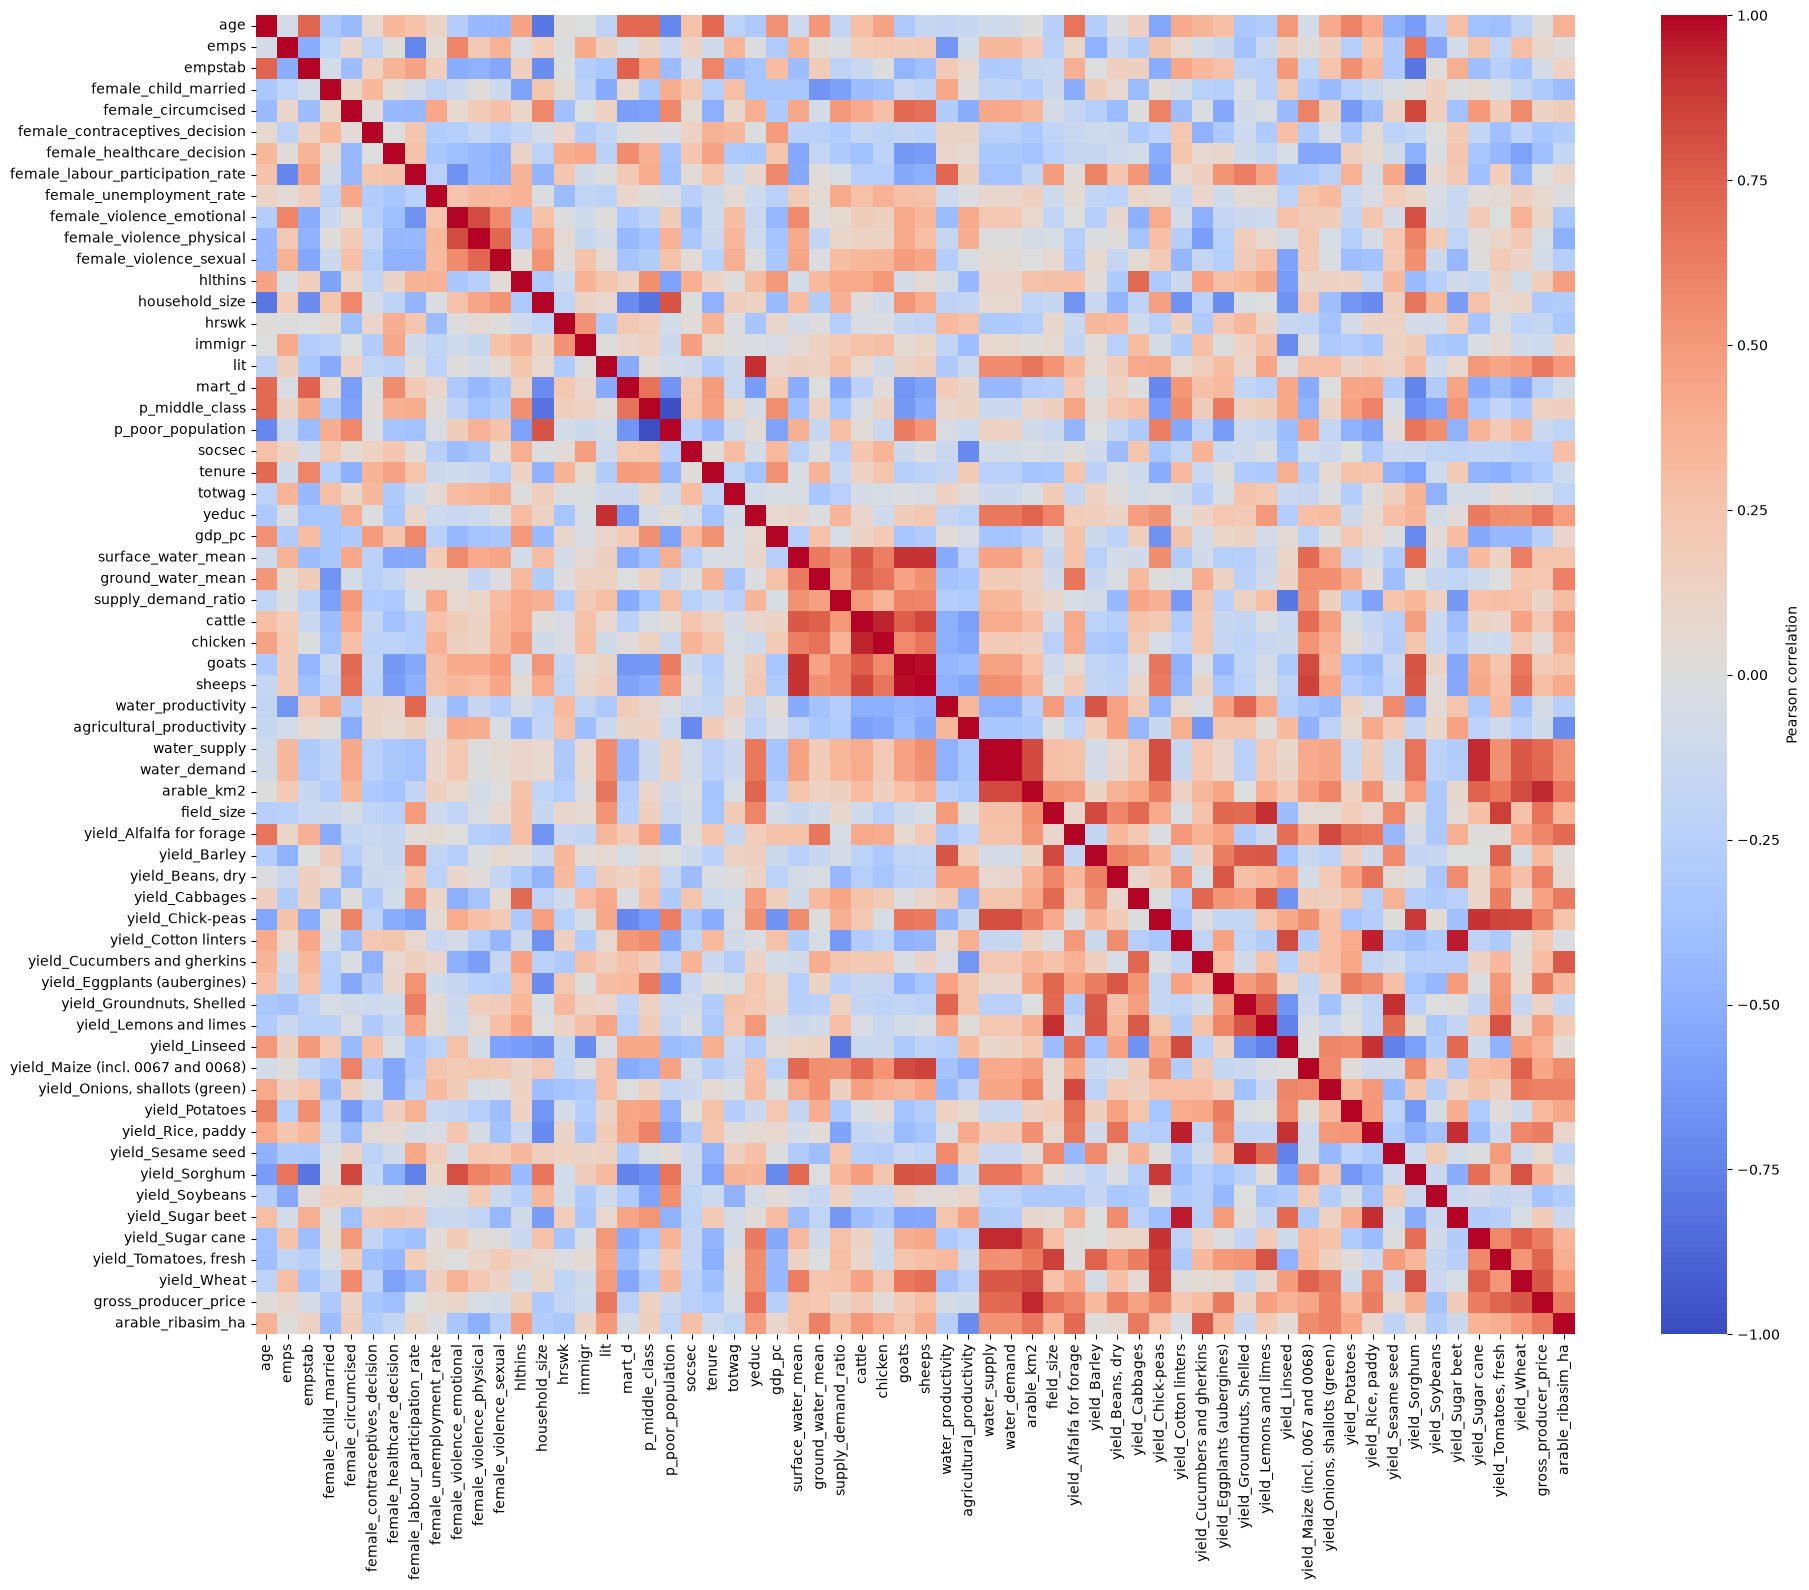

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pearson correlation for all numeric variables
corr = corelate_df.select_dtypes("number").corr(method="pearson")

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    cbar_kws={"label": "Pearson correlation"}
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


corr.columns = corr.columns.str.replace(",", " ", regex=False)

In [ ]:
corr.columns = corr.columns.str.replace(",", " ", regex=False)
corr.index = corr.index.str.replace(",", " ", regex=False)

# Convert correlation matrix to pairwise table
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)

corr_long = (
    corr.where(mask)
        .stack()
        .reset_index()
)

corr_long.columns = ["var1", "var2", "femalecorel"]

# Round correlation values
corr_long["femalecorel"] = corr_long["femalecorel"].round(2)

corr_long.to_csv("female.csv", index=False)

corr_long.head(20)

,var1,var2,femalecorel
0,age,age,NaN
1,age,emps,-0.06
2,age,empstab,0.73
3,age,female_child_married,-0.33
4,age,female_circumcised,-0.42
5,age,female_contraceptives_decision,0.07
6,age,female_healthcare_decision,0.33
7,age,female_labour_participation_rate,0.26
8,age,female_unemployment_rate,0.12
9,age,female_violence_emotional,-0.27
